# JS04 Regression - Lab 1
## Linear Regression

This lab explores the e-commerce customer dataset, trains a simple linear regression model, analyzes residuals, and evaluates predictions.

## Step 1-4: Data Preparation and Understanding

In [1]:
import numpy as np
import pandas as pd


data = pd.read_csv('dataset.csv')
print(f'Dataset shape: {data.shape}')
display(data.head())
data.info()
display(data.describe())

required_columns = [
    'Time on App', 'Time on Website', 'Length of Membership',
    'Yearly Amount Spent'
]
assert set(required_columns).issubset(data.columns)
assert data[required_columns].isna().sum().sum() == 0

Dataset shape: (500, 8)


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Step 5: Data Visualization

The scatter plots show the relationship between selected numeric predictors and the target. The heatmap shows correlations among numeric variables.

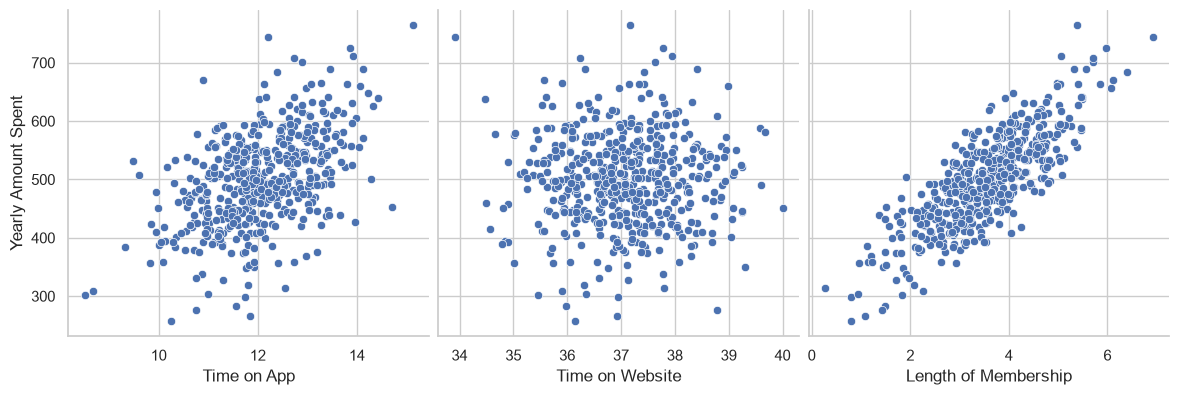

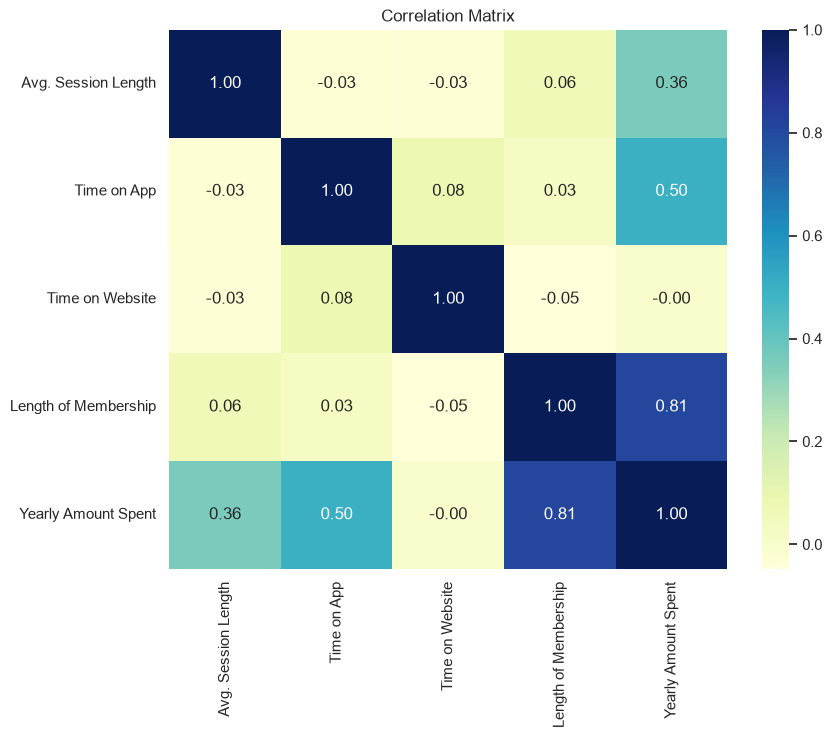

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
sns.pairplot(
    data,
    x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
    y_vars='Yearly Amount Spent',
    height=4,
    aspect=1,
    kind='scatter'
)
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(data.select_dtypes(include='number').corr(), cmap='YlGnBu', annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Step 6: Linear Regression

Following the module example, `Length of Membership` is used as the independent variable and `Yearly Amount Spent` as the target.

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.669
Model:                             OLS   Adj. R-squared:                  0.668
Method:                  Least Squares   F-statistic:                     702.9
Date:                 Tue, 29 Sep 2026   Prob (F-statistic):           1.59e-85
Time:                         14:43:39   Log-Likelihood:                -1841.3
No. Observations:                  350   AIC:                             3687.
Df Residuals:                      348   BIC:                             3694.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

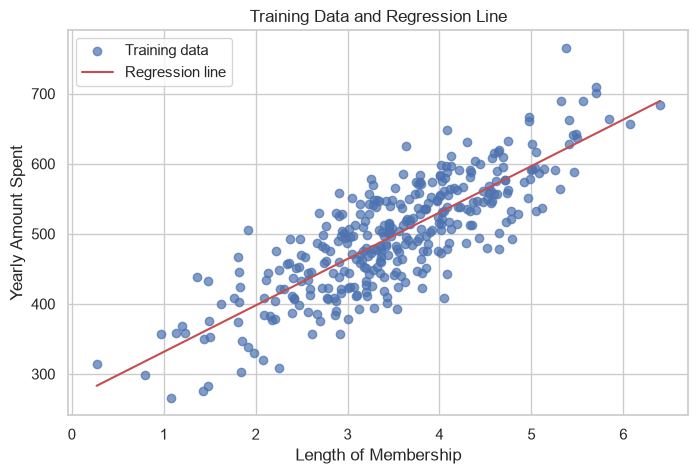

In [3]:
X = data['Length of Membership']
y = data['Yearly Amount Spent']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100
)

import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()
print(lr.summary())

intercept = lr.params['const']
slope = lr.params['Length of Membership']
print(f'Regression equation: y = {intercept:.4f} + {slope:.4f}x')

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.7, label='Training data')
sorted_train = X_train.sort_values()
plt.plot(sorted_train, intercept + slope * sorted_train, 'r', label='Regression line')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.title('Training Data and Regression Line')
plt.legend()
plt.show()

## Step 7: Residual Analysis

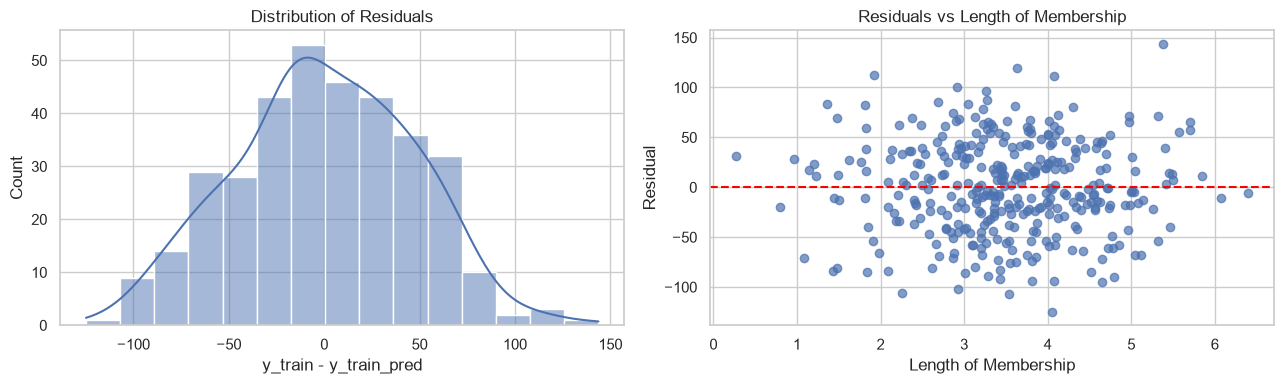

Mean residual: 0.000000


In [4]:
y_train_pred = lr.predict(X_train_sm)
res = y_train - y_train_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(res, bins=15, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals')
axes[0].set_xlabel('y_train - y_train_pred')
axes[1].scatter(X_train, res, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Length of Membership')
axes[1].set_xlabel('Length of Membership')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

print(f'Mean residual: {res.mean():.6f}')
assert len(res) == len(X_train)

## Step 8: Test Prediction and Model Evaluation

In [5]:
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r_squared = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'R-squared: {r_squared:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

assert len(y_test_pred) == len(y_test)
assert np.isfinite([r_squared, mae, rmse]).all()

R-squared: 0.6119
MAE: 36.8673
RMSE: 46.5980


## Step 9: Visualize Test Predictions

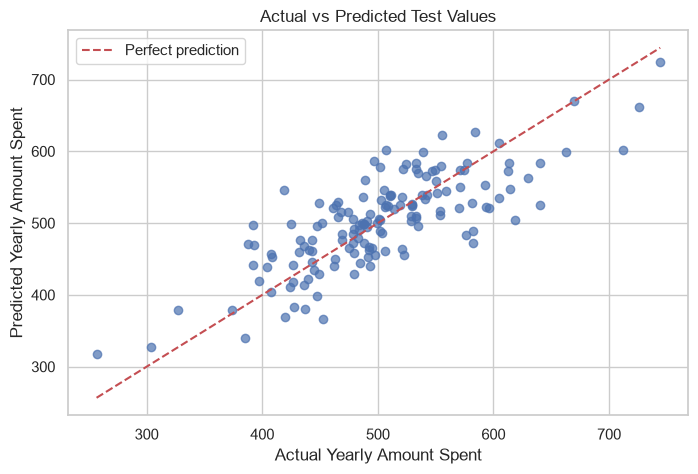

,Actual,Predicted
117,256.670582,317.594670
56,304.135592,327.339515
19,327.377953,378.450836
30,373.885724,379.006936
72,385.095007,340.200642


In [6]:
results = pd.DataFrame({
    'Actual': y_test.to_numpy(),
    'Predicted': y_test_pred.to_numpy()
}).sort_values('Actual')

plt.figure(figsize=(8, 5))
plt.scatter(results['Actual'], results['Predicted'], alpha=0.7)
line_min = min(results['Actual'].min(), results['Predicted'].min())
line_max = max(results['Actual'].max(), results['Predicted'].max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', label='Perfect prediction')
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted Test Values')
plt.legend()
plt.show()

display(results.head())

## Conclusion

The model was trained with a 70:30 train-test split. The test R-squared, MAE, RMSE, and residual plots provide complementary views of prediction quality.